# Handling at constant steer

Step 5.7. Steering fixed, speed in steps of 0.3 / 0.5 / 0.7 / 0.9 / 1.1 / 1.3 m/s,
6 s each, one continuous run (`drive_steps.py`). Slicks on tiles, LiPo nearly
full, 2026-09-24.

The plan was lateral acceleration from the accelerometer mean, which does not
depend on the slipping wheels. It does not work: while driving, the lateral
accelerometer has 1-4 m/s^2 of std, spikes up to 18 m/s^2 (tile joints), and
noise correlated over ~0.1 s, so a 4 s mean moves by up to 2 m/s^2. Below is
what the gyro and the wheels say on their own; a_y and mu wait for an external
position measurement.

In [1]:
import sys
sys.path.append('../scripts')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import bagtools as bt

L = 0.173
R_WHEEL = 0.0299
DELTA = {0.30: 17.83, 0.52: 27.43}      # steering map, kinematic_model.ipynb
STEPS = [0.3, 0.5, 0.7, 0.9, 1.1, 1.3]


def split_runs(drive):
    t = drive['t'].values
    gaps = np.flatnonzero(np.diff(t) > 2.0)
    return np.r_[t[0], t[gaps + 1]]


# (bag, run): handling run 0 hit the cushions, run 2 did not fit the space
runs = [('handling', 1), ('handling_b', 0)]

rows, series = [], {}
for bag, i in runs:
    d = bt.zero_time(bt.load(f'../data/{bag}_parquet'))
    js, drive, imu = d['joint_states'], d['drive'], d['imu_data_raw']
    starts = split_runs(drive)
    t0 = starts[i]
    bias = bt.window(imu, 0, starts[0] - 0.5)['gz'].median()    # at rest before the first run
    steer = round(bt.window(drive, t0 + 2, t0 + 3)['cmd_steer'].mean(), 2)
    tan_d = np.tan(np.radians(DELTA[steer]))
    series[steer] = (t0, js, imu, bias, tan_d)
    for k, cmd in enumerate(STEPS):
        a = t0 + 2 + k * 7 + 2          # skip ramp and first 2 s of each hold
        r = bt.window(imu, a, a + 4)['gz'].mean() - bias
        w = bt.window(js, a, a + 4)
        v = R_WHEEL * (w['wl'] + w['wr']).mean() / 2
        rows.append({'steer': steer, 'cmd [m/s]': cmd, 'v wheels [m/s]': v,
                     'r [rad/s]': r, 'r / r_kin': r / (v * tan_d / L)})

steps = pd.DataFrame(rows).round(3)
steps

/home/pietro/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


,steer,cmd [m/s],v wheels [m/s],r [rad/s],r / r_kin
0,0.30,0.3,0.301,0.480,0.858
1,0.30,0.5,0.501,0.793,0.852
2,0.30,0.7,0.701,1.083,0.831
3,0.30,0.9,0.901,1.374,0.821
4,0.30,1.1,1.101,1.558,0.761
5,0.30,1.3,1.175,1.518,0.695
6,0.52,0.3,0.301,0.785,0.871
7,0.52,0.5,0.500,1.298,0.865
8,0.52,0.7,0.700,1.776,0.845
9,0.52,0.9,0.900,2.230,0.826


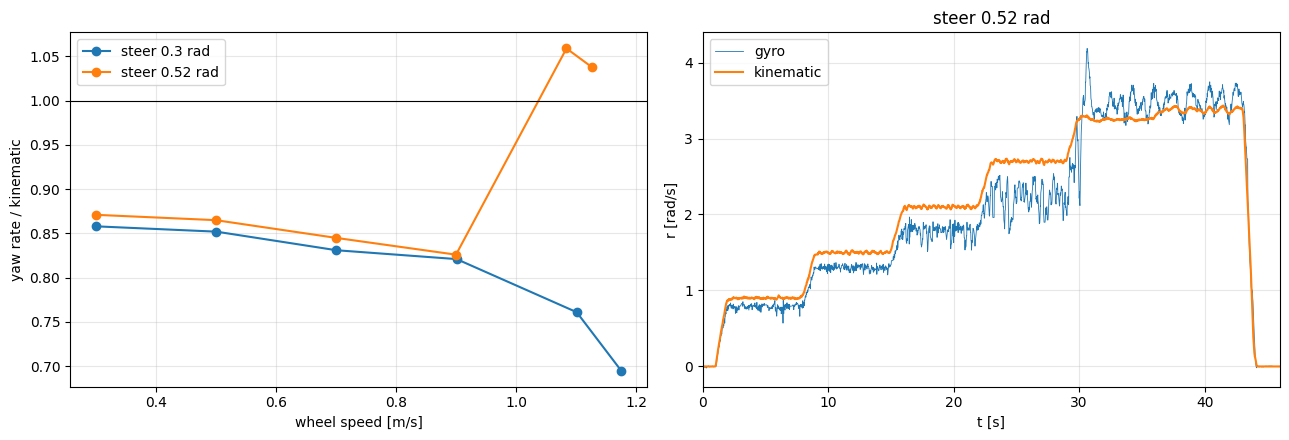

In [2]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
for steer, g in steps.groupby('steer'):
    ax[0].plot(g['v wheels [m/s]'], g['r / r_kin'], 'o-', label=f'steer {steer} rad')
ax[0].axhline(1, color='k', lw=0.8)
ax[0].set_xlabel('wheel speed [m/s]')
ax[0].set_ylabel('yaw rate / kinematic')
ax[0].grid(alpha=0.3)
ax[0].legend()

t0, js, imu, bias, tan_d = series[0.52]
ax[1].plot(imu['t'] - t0, imu['gz'] - bias, lw=0.6, label='gyro')
ax[1].plot(js['t'] - t0, R_WHEEL * (js['wl'] + js['wr']) / 2 * tan_d / L, label='kinematic')
ax[1].set_xlim(0, 46)
ax[1].set_xlabel('t [s]')
ax[1].set_ylabel('r [rad/s]')
ax[1].set_title('steer 0.52 rad')
ax[1].grid(alpha=0.3)
ax[1].legend()
plt.tight_layout()
plt.show()

At 0.30 rad the yaw rate falls behind the kinematic one as speed grows, from
0.86 to 0.70 of it: the car runs wide. At full lock it stays at 0.83-0.87 up to
0.9 m/s, then between 0.9 and 1.1 m/s the rear lets go and the yaw rate jumps
above the kinematic value (1.06). From there the car holds a **steady drift at
~3.5 rad/s** with the motors at free speed, and stays in place.

The ratio below 1 is the spool (step 5.5). Above 1 the car turns tighter than
the geometry allows while the wheels spin faster than it moves, so neither the
radius nor the speed can be read from the wheels. Next session: overhead video
with markers on the car, for radius, true speed and sideslip.